In [1]:
# Instalar o kaggle para baixar o dataset
!pip install kaggle -q

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rafaelfranck","key":"18067d9ab60c266a4a6e54ddd49959e3"}'}

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle configurado!")

Kaggle configurado!


In [4]:
# Baixar o PlantVillage
!kaggle datasets download -d emmarex/plantdisease -p /content/plantvillage --unzip -q
print("Download concluído!")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
Download concluído!


In [5]:
import os
base_path = '/content/plantvillage/PlantVillage'
classes_originais = sorted(os.listdir(base_path))
print(f"Total de classes no dataset: {len(classes_originais)}")
print("\nClasses encontradas:")
for c in classes_originais:
    print(c)

Total de classes no dataset: 15

Classes encontradas:
Pepper__bell___Bacterial_spot
Pepper__bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Tomato_mosaic_virus
Tomato_healthy


In [6]:
import os
import shutil
from pathlib import Path

# Mapeamento das classes
mapeamento = {
    'saudavel': [
        'Pepper__bell___healthy',
        'Potato___healthy',
        'Tomato_healthy'
    ],
    'estresse': [
        'Potato___Early_blight',
        'Potato___Late_blight',
        'Tomato_Early_blight',
        'Tomato_Late_blight',
        'Tomato_Leaf_Mold',
        'Tomato_Spider_mites_Two_spotted_spider_mite'
    ],
    'fungo_patogeno': [
        'Pepper__bell___Bacterial_spot',
        'Tomato_Bacterial_spot',
        'Tomato_Septoria_leaf_spot',
        'Tomato__Target_Spot',
        'Tomato__Tomato_YellowLeaf__Curl_Virus',
        'Tomato__Tomato_mosaic_virus'
    ]
}

base_path = '/content/plantvillage/PlantVillage'
dest_path = '/content/jamestown_dataset'

# Criar pastas de destino
for classe in mapeamento:
    Path(f'{dest_path}/{classe}').mkdir(parents=True, exist_ok=True)

# Copiar imagens
total = 0
for classe, pastas in mapeamento.items():
    count = 0
    for pasta in pastas:
        origem = f'{base_path}/{pasta}'
        if os.path.exists(origem):
            for img in os.listdir(origem):
                if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                    shutil.copy(
                        f'{origem}/{img}',
                        f'{dest_path}/{classe}/{img}'
                    )
                    count += 1
    print(f'{classe}: {count} imagens')
    total += count

print(f'\nTotal geral: {total} imagens')

saudavel: 3221 imagens
estresse: 7537 imagens
fungo_patogeno: 9880 imagens

Total geral: 20638 imagens


In [7]:
import os
import shutil
import random
from pathlib import Path

random.seed(42)

source_path = '/content/jamestown_dataset'
split_path = '/content/jamestown_split'
classes = ['saudavel', 'estresse', 'fungo_patogeno']

# Limitar todas as classes a 3000 imagens
MAX_POR_CLASSE = 3000
SPLIT = {'train': 0.70, 'val': 0.15, 'test': 0.15}

# Criar estrutura de pastas
for split in SPLIT:
    for classe in classes:
        Path(f'{split_path}/{split}/{classe}').mkdir(parents=True, exist_ok=True)

# Distribuir imagens
for classe in classes:
    imagens = os.listdir(f'{source_path}/{classe}')
    imagens = [i for i in imagens if i.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(imagens)
    imagens = imagens[:MAX_POR_CLASSE]  # limita a 3000

    n = len(imagens)
    n_train = int(n * 0.70)
    n_val   = int(n * 0.15)

    splits = {
        'train': imagens[:n_train],
        'val':   imagens[n_train:n_train + n_val],
        'test':  imagens[n_train + n_val:]
    }

    for split, arquivos in splits.items():
        for arquivo in arquivos:
            shutil.copy(
                f'{source_path}/{classe}/{arquivo}',
                f'{split_path}/{split}/{classe}/{arquivo}'
            )

# Conferir resultado
print("Distribuição final:\n")
for split in ['train', 'val', 'test']:
    print(f"  {split}:")
    for classe in classes:
        n = len(os.listdir(f'{split_path}/{split}/{classe}'))
        print(f"    {classe}: {n} imagens")


Distribuição final:

  train:
    saudavel: 2100 imagens
    estresse: 2100 imagens
    fungo_patogeno: 2100 imagens
  val:
    saudavel: 450 imagens
    estresse: 450 imagens
    fungo_patogeno: 450 imagens
  test:
    saudavel: 450 imagens
    estresse: 450 imagens
    fungo_patogeno: 450 imagens


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Treino: com augmentation leve
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Validação e teste: só normalização, sem augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Carrega as imagens das pastas
train_gen = train_datagen.flow_from_directory(
    '/content/jamestown_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    '/content/jamestown_split/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

test_gen = val_test_datagen.flow_from_directory(
    '/content/jamestown_split/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,  # mantem ordem para a matriz de confusão
    seed=42
)

print("Classes mapeadas:", train_gen.class_indices)

Found 6300 images belonging to 3 classes.
Found 1350 images belonging to 3 classes.
Found 1350 images belonging to 3 classes.
Classes mapeadas: {'estresse': 0, 'fungo_patogeno': 1, 'saudavel': 2}


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ── Arquitetura CNN A - Leve ──
cnn_a = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')  # 3 classes
], name='CNN_A_Leve')

cnn_a.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_a.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_A_Leve"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Iniciando treino da CNN A...")

history_a = cnn_a.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1
)

# Salvar o modelo
cnn_a.save('/content/cnn_a_jamestown.h5')
print("\nCNN A salva!")

Iniciando treino da CNN A...
Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 48s 208ms/step - accuracy: 0.5465 - loss: 0.9048 - val_accuracy: 0.7393 - val_loss: 0.6828
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 36s 185ms/step - accuracy: 0.7646 - loss: 0.5847 - val_accuracy: 0.7630 - val_loss: 0.5949
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 37s 187ms/step - accuracy: 0.8175 - loss: 0.4593 - val_accuracy: 0.7874 - val_loss: 0.5119
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 36s 183ms/step - accuracy: 0.8513 - loss: 0.3775 - val_accuracy: 0.8637 - val_loss: 0.3364
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 36s 182ms/step - accuracy: 0.8698 - loss: 0.3216 - val_accuracy: 0.8385 - val_loss: 0.4259
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 36s 182ms/step - accuracy: 0.8808 - loss: 0.3038 - val_accuracy: 0.8244 - val_loss: 0.5782
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 36s 182ms/step - accuracy: 0.8984 - loss: 0.2512 - val_accuracy: 0.8911 - val_loss: 0.3059
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 37s 186ms/step


CNN A salva!


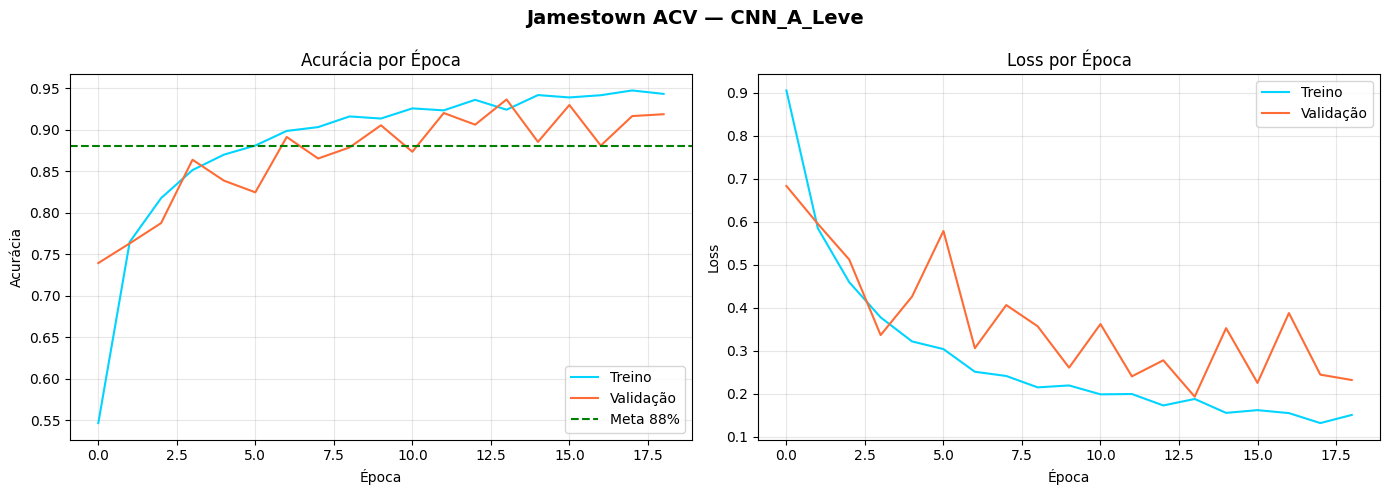

Gráfico salvo!


In [11]:
import matplotlib.pyplot as plt

def plotar_historico(history, nome_modelo):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Jamestown ACV — {nome_modelo}', fontsize=14, fontweight='bold')

    # Acurácia
    ax1.plot(history.history['accuracy'], label='Treino', color='#00d4ff')
    ax1.plot(history.history['val_accuracy'], label='Validação', color='#ff6b35')
    ax1.axhline(y=0.88, color='green', linestyle='--', label='Meta 88%')
    ax1.set_title('Acurácia por Época')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Acurácia')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history['loss'], label='Treino', color='#00d4ff')
    ax2.plot(history.history['val_loss'], label='Validação', color='#ff6b35')
    ax2.set_title('Loss por Época')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'/content/{nome_modelo}_historico.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Gráfico salvo!")

plotar_historico(history_a, 'CNN_A_Leve')

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input

# ── Arquitetura CNN B - Profunda ──
cnn_b = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
], name='CNN_B_Profunda')

cnn_b.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_b.summary()

Model: "CNN_B_Profunda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,618,179 (17.62 MB)

 Trainable params: 4,617,219 (17.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
early_stop_b = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Iniciando treino da CNN B...")

history_b = cnn_b.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[early_stop_b],
    verbose=1
)

cnn_b.save('/content/cnn_b_jamestown.keras')
print("\nCNN B salva!")

Iniciando treino da CNN B...
Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 53s 221ms/step - accuracy: 0.5544 - loss: 1.5286 - val_accuracy: 0.3333 - val_loss: 7.3339
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 36s 183ms/step - accuracy: 0.6227 - loss: 0.8321 - val_accuracy: 0.4089 - val_loss: 3.4867
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 36s 185ms/step - accuracy: 0.5990 - loss: 0.8733 - val_accuracy: 0.5000 - val_loss: 1.6612
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 37s 190ms/step - accuracy: 0.6629 - loss: 0.7742 - val_accuracy: 0.4800 - val_loss: 2.4820
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 37s 187ms/step - accuracy: 0.7144 - loss: 0.6563 - val_accuracy: 0.7089 - val_loss: 1.2392
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 37s 187ms/step - accuracy: 0.7554 - loss: 0.5735 - val_accuracy: 0.7304 - val_loss: 1.1626
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 39s 198ms/step - accuracy: 0.7714 - loss: 0.5293 - val_accuracy: 0.7578 - val_loss: 0.9602
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 38s 191ms/step

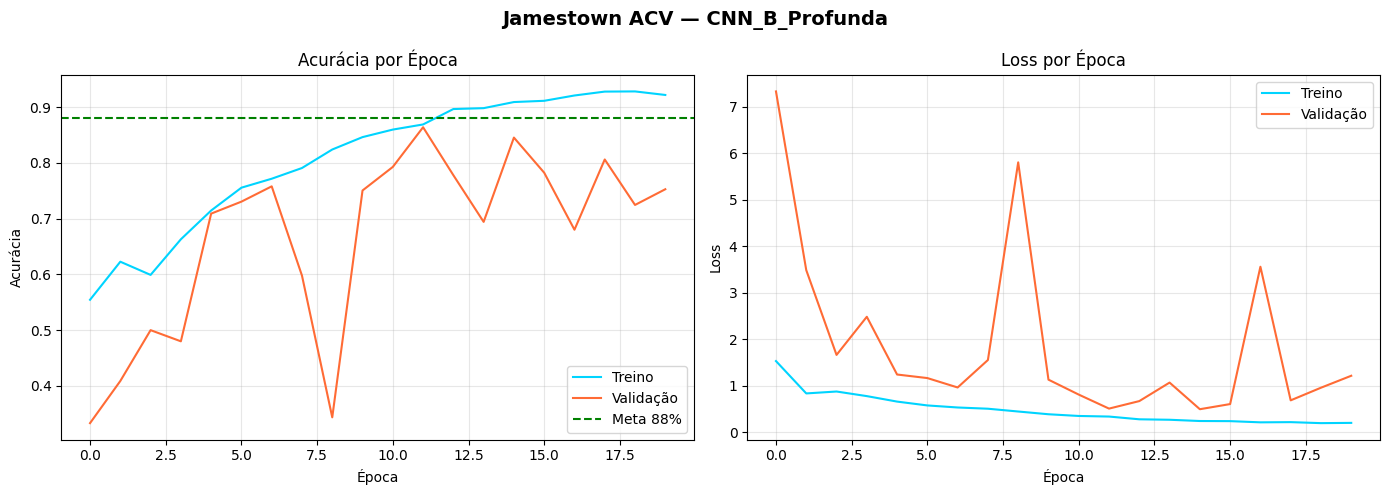

Gráfico salvo!


In [14]:
plotar_historico(history_b, 'CNN_B_Profunda')


Avaliando CNN A no conjunto de teste...
CNN A — Acurácia no teste: 0.9237 (92.37%)
CNN A — Loss no teste: 0.1869

Relatório de Classificação:
                precision    recall  f1-score   support

      estresse       0.90      0.91      0.91       450
fungo_patogeno       0.92      0.87      0.89       450
      saudavel       0.95      0.99      0.97       450

      accuracy                           0.92      1350
     macro avg       0.92      0.92      0.92      1350
  weighted avg       0.92      0.92      0.92      1350



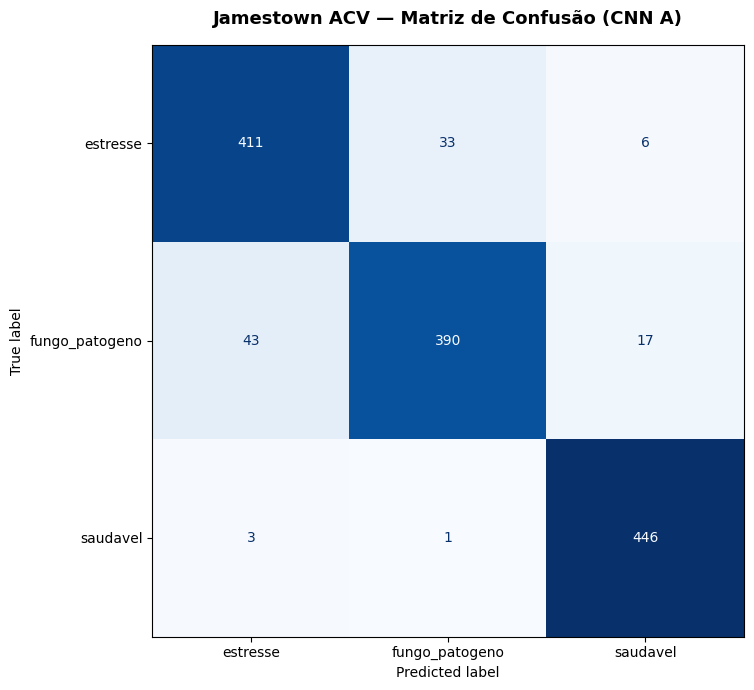

Matriz salva!


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

# Resetar o gerador de teste
test_gen.reset()

# Predições da CNN A no conjunto de teste
print("Avaliando CNN A no conjunto de teste...")
loss_a, acc_a = cnn_a.evaluate(test_gen, verbose=0)
print(f"CNN A — Acurácia no teste: {acc_a:.4f} ({acc_a*100:.2f}%)")
print(f"CNN A — Loss no teste: {loss_a:.4f}")

# Gerar predições
test_gen.reset()
y_pred_probs = cnn_a.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Nomes das classes
class_names = list(test_gen.class_indices.keys())

# Relatório completo
print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Jamestown ACV — Matriz de Confusão (CNN A)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/content/CNN_A_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Matriz salva!")

In [16]:
import json
from datetime import datetime, timezone

# Simular predição de uma amostra nova
def gerar_saida_jamestown(modelo, img_path_simulada, sample_id, greenhouse_id):
    class_names = ['estresse', 'fungo_patogeno', 'saudavel']

    # Pega uma imagem real do conjunto de teste
    test_gen.reset()
    batch_x, _ = next(test_gen)
    img = batch_x[0:1]  # primeira imagem do batch

    pred = modelo.predict(img, verbose=0)
    classe_idx = int(np.argmax(pred[0]))
    confianca = float(np.max(pred[0]))

    saida = {
        "sample_id": sample_id,
        "greenhouse_id": greenhouse_id,
        "sector": greenhouse_id,
        "predicted_class": classe_idx,
        "predicted_label": class_names[classe_idx],
        "leaf_status": class_names[classe_idx],
        "confidence": round(confianca, 4),
        "model_version": "cnn_a_v1",
        "model_name": "CNN_A_Leve",
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "created_at": datetime.now(timezone.utc).isoformat()
    }
    return saida

saida = gerar_saida_jamestown(
    cnn_a,
    "samples/GH01_0042.jpg",
    "JAM-GH01-SMP-0042",
    "GH-01"
)

print("Saída JSON gerada:")
print(json.dumps(saida, indent=2))

with open('/content/jamestown_sample_output.json', 'w') as f:
    json.dump(saida, f, indent=2)

print("\nJSON salvo!")

Saída JSON gerada:
{
  "sample_id": "JAM-GH01-SMP-0042",
  "greenhouse_id": "GH-01",
  "sector": "GH-01",
  "predicted_class": 0,
  "predicted_label": "estresse",
  "leaf_status": "estresse",
  "confidence": 1.0,
  "model_version": "cnn_a_v1",
  "model_name": "CNN_A_Leve",
  "timestamp": "2026-05-27T03:14:23.064060+00:00",
  "created_at": "2026-05-27T03:14:23.064080+00:00"
}

JSON salvo!


In [17]:
!pip install gradio -q

In [18]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image
import json
from datetime import datetime, timezone

class_names = ['estresse', 'fungo_patogeno', 'saudavel']
class_labels = {
    'estresse':       '⚠️ Estresse Hídrico/Nutricional',
    'fungo_patogeno': '🔴 Fungo / Patógeno Detectado',
    'saudavel':       '✅ Saudável'
}
class_colors = {
    'estresse':       'orange',
    'fungo_patogeno': 'red',
    'saudavel':       'green'
}

def diagnosticar(imagem, sector_id):
    if imagem is None:
        return "Nenhuma imagem enviada.", "{}"

    # Pré-processar
    img = Image.fromarray(imagem).resize((128, 128))
    arr = np.array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    # Predição
    pred = cnn_a.predict(arr, verbose=0)
    classe_idx = int(np.argmax(pred[0]))
    confianca  = float(np.max(pred[0]))
    classe     = class_names[classe_idx]
    label      = class_labels[classe]

    # Gerar JSON de saída
    sample_id = f"JAM-{sector_id}-SMP-{datetime.now().strftime('%H%M%S')}"
    saida = {
        "sample_id":       sample_id,
        "greenhouse_id":   sector_id,
        "sector":          sector_id,
        "predicted_class": classe_idx,
        "predicted_label": classe,
        "leaf_status":     classe,
        "confidence":      round(confianca, 4),
        "model_version":   "cnn_a_v1",
        "timestamp":       datetime.now(timezone.utc).isoformat(),
        "recommended_action": (
            "Monitorar ciclos de irrigação e nutrientes" if classe == 'estresse' else
            "ISOLAR SETOR — Acionar protocolo antifúngico" if classe == 'fungo_patogeno' else
            "Nenhuma ação necessária"
        )
    }

    resultado = f"""
## {label}

**Confiança:** {confianca*100:.1f}%
**Setor:** {sector_id}
**Sample ID:** {sample_id}
**Ação recomendada:** {saida['recommended_action']}
"""
    return resultado, json.dumps(saida, indent=2)

# Interface
with gr.Blocks(title="Jamestown ACV") as demo:
    gr.Markdown("""
    # 🌿 Jamestown Autonomous Hub
    ## Terminal de Diagnóstico Botânico
    *Applied Computer Vision — Global Solution FIAP 2026*
    """)

    with gr.Row():
        with gr.Column():
            imagem_input = gr.Image(label="Imagem da Amostra Foliar")
            sector_input = gr.Textbox(value="GH-01", label="ID do Setor")
            btn = gr.Button("🔍 Analisar Amostra", variant="primary")
        with gr.Column():
            resultado_output = gr.Markdown(label="Diagnóstico")
            json_output = gr.Code(label="Saída JSON (integração)", language="json")

    btn.click(
        fn=diagnosticar,
        inputs=[imagem_input, sector_input],
        outputs=[resultado_output, json_output]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c8b26659d2a7a9e0e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [19]:
import shutil

# Pegar uma imagem de cada classe do conjunto de teste
for classe in ['estresse', 'fungo_patogeno', 'saudavel']:
    pasta = f'/content/jamestown_split/test/{classe}'
    primeira_img = os.listdir(pasta)[0]
    shutil.copy(
        f'{pasta}/{primeira_img}',
        f'/content/exemplo_{classe}.jpg'
    )
    print(f"Salvo: exemplo_{classe}.jpg")

Salvo: exemplo_estresse.jpg
Salvo: exemplo_fungo_patogeno.jpg
Salvo: exemplo_saudavel.jpg


In [20]:
from google.colab import files
files.download('/content/exemplo_estresse.jpg')
files.download('/content/exemplo_fungo_patogeno.jpg')
files.download('/content/exemplo_saudavel.jpg')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
readme = """# 🌿 Jamestown ACV — Applied Computer Vision
## Global Solution FIAP 2026 — Engenharia de Software

---

## 📋 Sobre o Projeto

O módulo de **Applied Computer Vision** do Jamestown Autonomous Hub é responsável pela triagem visual autônoma de amostras foliares coletadas.

A CNN analisa a imagem da folha e classifica sua condição, gerando um diagnóstico em JSON que alimenta o pipeline de Big Data (BDDI), o modelo preditivo (GAIE) e o bot de contingência (RPA).

---

## 🎯 Classes de Diagnóstico

| Classe | Label | Descrição |
|--------|-------|-----------|
| 0 | `estresse` | Desidratação, deficiência mineral ou desequilíbrio de cultivo |
| 1 | `fungo_patogeno` | Necrose, manchas fúngicas ou risco microbiológico |
| 2 | `saudavel` | Folha com coloração e estrutura compatíveis com cultivo estável |

---

## 📁 Dataset

- **Fonte:** PlantVillage (adaptado para contexto espacial)
- **Total:** 9.000 imagens balanceadas (3.000 por classe)
- **Divisão:** 70% treino / 15% validação / 15% teste
- **Pré-processamento:** redimensionamento 128x128, normalização 0-1
- **Augmentation:** rotação ±15°, zoom 10%, flip horizontal, variação de brilho

---

## 🧠 Arquiteturas CNN

### CNN A — Leve (modelo selecionado)
- 3 blocos Conv2D + ReLU + MaxPooling
- Flatten → Dense(128) → Dropout(0.4) → Softmax
- **3.305.027 parâmetros**
- **Acurácia no teste: 92,37%** ✅

### CNN B — Profunda
- 4 blocos Conv2D + BatchNormalization + MaxPooling
- Dense(256) → Dropout(0.5) → Dense(128) → Dropout(0.3) → Softmax
- **4.618.179 parâmetros**
- Apresentou overfitting — validação instável (~86%)

### Por que a CNN A foi escolhida?
A CNN B, apesar de mais profunda, apresentou instabilidade na validação com loss chegando a 7.3 em alguns epochs. A CNN A demonstrou curvas mais estáveis e acurácia de validação superior (93,6%), sendo mais adequada para operação em ambiente de missão crítica.

---

## 📊 Métricas — CNN A (conjunto de teste)

| Classe | Precision | Recall | F1-Score |
|--------|-----------|--------|----------|
| estresse | 0.90 | 0.91 | 0.91 |
| fungo_patogeno | 0.92 | 0.87 | 0.89 |
| saudavel | 0.95 | 0.99 | 0.97 |
| **média** | **0.92** | **0.92** | **0.92** |

> **Destaque operacional:** fungo classificado como saudável ocorreu apenas 1 vez em 450 testes — risco crítico minimizado.

---

## 🔗 Saída JSON (integração com o ecossistema)

```json
{
  "sample_id": "JAM-GH01-SMP-0042",
  "greenhouse_id": "GH-01",
  "sector": "GH-01",
  "predicted_class": 1,
  "predicted_label": "fungo_patogeno",
  "leaf_status": "fungo_patogeno",
  "confidence": 0.9957,
  "model_version": "cnn_a_v1",
  "timestamp": "2026-05-27T03:19:05Z",
  "recommended_action": "ISOLAR SETOR — Acionar protocolo antifúngico"
}
```

---

## 🚀 Como executar

### Opção 1 — Google Colab (recomendado)
1. Abra o notebook `jamestown_acv.ipynb` no Google Colab
2. Ative GPU: **Ambiente de execução → T4 GPU**
3. Execute todas as células em ordem
4. A interface Gradio abrirá automaticamente com link público

### Opção 2 — Local
```bash
pip install tensorflow gradio scikit-learn matplotlib
jupyter notebook jamestown_acv.ipynb
```

---

## 📂 Estrutura do repositório
acv/
├── notebooks/
│   └── jamestown_acv.ipynb
├── models/
│   ├── cnn_a_jamestown.h5
│   └── cnn_b_jamestown.keras
├── evidencias/
│   ├── CNN_A_Leve_historico.png
│   ├── CNN_B_Profunda_historico.png
│   └── CNN_A_matriz_confusao.png
├── data/
│   └── jamestown_sample_output.json
└── README.md

---

## 🔄 Integração no Ecossistema Jamestown
PBML (braço coleta amostra)
↓
ACV (CNN classifica folha)
↓
BDDI (Airflow ingere o JSON)
↓
GAIE (modelo prevê risco + SHAP)
↓
BISD (dashboard exibe alerta)
↓
RPA (abre incidente + envia e-mail)
↓
SDTCC (Azure monitora tudo)

---

## 👥 Equipe

**Jamestown Autonomous Hub — Global Solution FIAP 2026**
Engenharia de Software — 4º Ano
Rafael Franck RM550875
Gabriela Trevisan RM99500
Breno Silva RM99275
Eduardo Araujo RM99758
Gustavo Akio RM550241
---

## 📎 ODS Relacionados

- **ODS 2** — Fome zero e agricultura sustentável
- **ODS 9** — Indústria, inovação e infraestrutura
"""

with open('/content/README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("README gerado!")

README gerado!


In [25]:
from google.colab import files
files.download('/content/README.md')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from google.colab import files
import os

print("Baixando todos os arquivos...")

# Modelos
files.download('/content/cnn_a_jamestown.h5')
files.download('/content/cnn_b_jamestown.keras')

# Gráficos
files.download('/content/CNN_A_Leve_historico.png')
files.download('/content/CNN_B_Profunda_historico.png')
files.download('/content/CNN_A_matriz_confusao.png')

# JSON de exemplo
files.download('/content/jamestown_sample_output.json')

# README
files.download('/content/README.md')

# Imagens de exemplo
files.download('/content/exemplo_estresse.jpg')
files.download('/content/exemplo_fungo_patogeno.jpg')
files.download('/content/exemplo_saudavel.jpg')

print("Tudo baixado!")

Baixando todos os arquivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tudo baixado!
